In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from PIL import Image
from sklearn.metrics import classification_report
import zipfile

zip_path = "/content/drive/MyDrive/Bipin/AIML/FruitinAmazon.zip"
extract_dir = "/content/FruitinAmazon"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

train_dir = os.path.join(extract_dir, 'FruitinAmazon', 'train')
test_dir = os.path.join(extract_dir, 'FruitinAmazon', 'test')

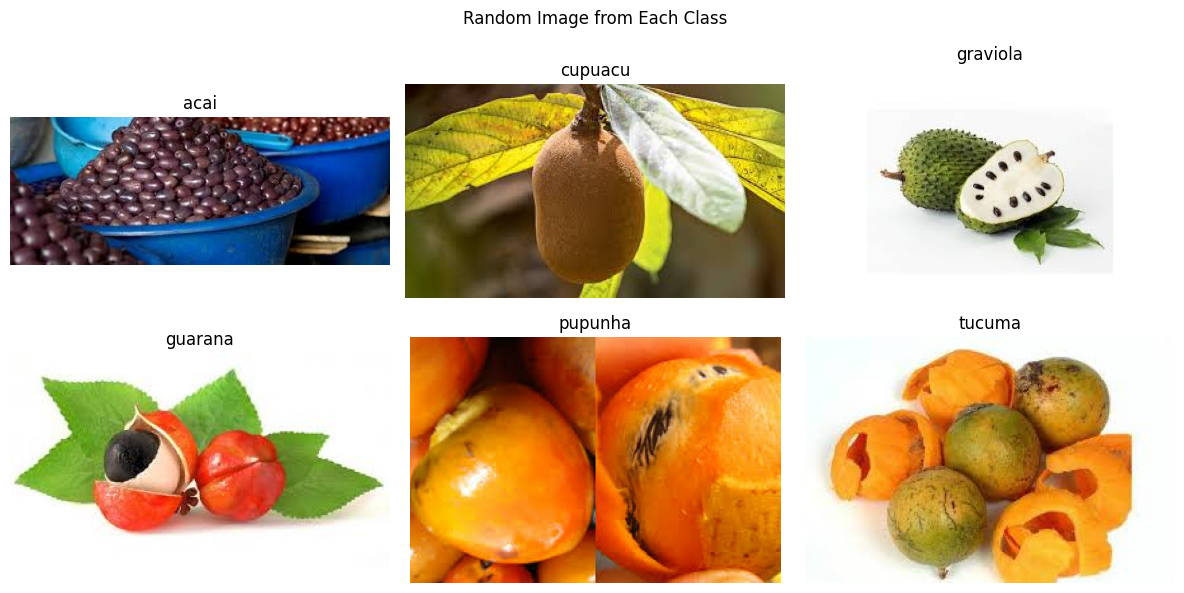

Expected Output: No corrupted images found.


In [5]:
# 1.1 Load and visualize images
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

plt.figure(figsize=(12, 6))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        random_image = random.choice(images)
        img_path = os.path.join(class_path, random_image)
        img = Image.open(img_path)

        # Display in a grid with 2 rows
        plt.subplot(2, (num_classes + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
plt.suptitle("Random Image from Each Class")
plt.tight_layout()
plt.show()

# 1.2 Check for Corrupted Images
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError) as e:
            print(f"Corrupted image found: {img_path} - Error: {e}")
            corrupted_images.append(img_path)

if not corrupted_images:
    print("Expected Output: No corrupted images found.")
else:
    print(f"Found {len(corrupted_images)} corrupted images.")

In [6]:
# 2.1 Data Preprocessing and Augmentation
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# Data Augmentation for Training Data
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for Test Data (no augmentation)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Data Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Data generators created successfully.")

Found 90 images belonging to 6 classes.
Found 30 images belonging to 6 classes.
Data generators created successfully.


In [8]:
model = models.Sequential()

# Convolutional Layer 1 & Pooling Layer 1
model.add(layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# Convolutional Layer 2 & Pooling Layer 2
model.add(layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# Fully Connected Network Architecture
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu')) # Hidden Layer 1
model.add(layers.Dense(64, activation='relu'))  # Hidden Layer 2
model.add(layers.Dense(num_classes, activation='softmax')) # Output Layer

# Print out the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43808)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,607,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,626,342 (21.46 MB)

 Trainable params: 5,626,342 (21.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.1623 - loss: 3.2734

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1778 - loss: 3.9126 - val_accuracy: 0.1667 - val_loss: 2.4069
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.1052 - loss: 2.3558

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.1778 - loss: 2.1615 - val_accuracy: 0.3000 - val_loss: 1.7492
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.1923 - loss: 1.8301

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2333 - loss: 1.7575 - val_accuracy: 0.3333 - val_loss: 1.6303
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4376 - loss: 1.6501

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4222 - loss: 1.6367 - val_accuracy: 0.2667 - val_loss: 1.5393
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.4027 - loss: 1.5309

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 990ms/step - accuracy: 0.7556 - loss: 0.6157 - val_accuracy: 0.7667 - val_loss: 0.5407
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7333 - loss: 0.6169 - val_accuracy: 0.7333 - val_loss: 0.6102
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8333 - loss: 0.5502 - val_accuracy: 0.7667 - val_loss: 0.5700
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 896ms/step - accuracy: 0.7889 - loss: 0.5404 - val_accuracy: 0.6333 - val_loss: 0.6995
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8398 - loss: 0.4631

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8111 - loss: 0.4492 - val_accuracy: 0.8000 - val_loss: 0.4828
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8291 - loss: 0.4318

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.8333 - loss: 0.4355 - val_accuracy: 0.9000 - val_loss: 0.4361
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 960ms/step - accuracy: 0.7556 - loss: 0.5525 - val_accuracy: 0.8333 - val_loss: 0.5134
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8333 - loss: 0.4771 - val_accuracy: 0.7333 - val_loss: 0.5808
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8333 - loss: 0.4153 - val_accuracy: 0.6333 - val_loss: 0.6849
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7889 - loss: 0.4522 - val_accuracy: 0.7667 - val_loss: 0.5078
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.8003 - loss: 0.4209

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8000 - loss: 0.4056 - val_accuracy: 0.8000 - val_loss: 0.4307
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 935ms/step - accuracy: 0.8444 - loss: 0.3704 - val_accuracy: 0.7333 - val_loss: 0.6374
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9111 - loss: 0.3114 - val_accuracy: 0.7000 - val_loss: 0.6397
Epoch 32/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 918ms/step - accuracy: 0.8667 - loss: 0.3664 - val_accuracy: 0.8333 - val_loss: 0.4739
Epoch 33/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 927ms/step - accuracy: 0.8889 - loss: 0.3205 - val_accuracy: 0.7333 - val_loss: 0.5330
Epoch 34/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.8563 - loss: 0.4027

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8778 - loss: 0.3809 - val_accuracy: 0.8333 - val_loss: 0.4307
Epoch 35/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9111 - loss: 0.3265 - val_accuracy: 0.8667 - val_loss: 0.4497
Epoch 36/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8556 - loss: 0.3665 - val_accuracy: 0.7667 - val_loss: 0.5454
Epoch 37/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 928ms/step - accuracy: 0.8889 - loss: 0.3063 - val_accuracy: 0.7667 - val_loss: 0.5415
Epoch 38/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8444 - loss: 0.3578 - val_accuracy: 0.8333 - val_loss: 0.5292
Epoch 39/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9000 - loss: 0.3283 - val_accuracy: 0.7000 - val_loss: 0.7026
Epoch 40/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8889 - loss: 0.2916 - val_accuracy: 0.7667 - val_loss: 0.5041
Epoch 41/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 934ms/step - accuracy: 0.8889 - loss: 0.2965 - val_accuracy: 0.8333 - val_loss: 0.4374
Epoch 4

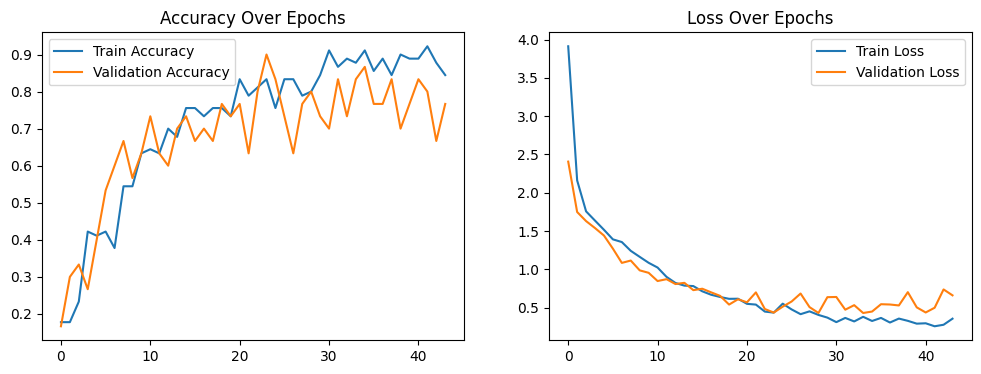

In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks for saving best model and avoiding overfitting
checkpoint = callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=250,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Plotting Training and Validation Graphs
plt.figure(figsize=(12, 4))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.show()

In [12]:
test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

1/1 - 0s - 281ms/step - accuracy: 0.8333 - loss: 0.4307
Final Test Accuracy: 0.8333
Final Test Loss: 0.4307


In [15]:
model.save('amazon_fruits_model.h5')
print("Model successfully saved as 'amazon_fruits_model.h5'")

# Load the saved model
loaded_model = models.load_model('amazon_fruits_model.h5')
print("Model successfully loaded from disk.")

# Re-evaluate to verify it loaded correctly
load_loss, load_acc = loaded_model.evaluate(validation_generator, verbose=0)
print(f"Loaded Model Accuracy: {load_acc:.4f}")

Model successfully saved as 'amazon_fruits_model.h5'


Model successfully loaded from disk.
Loaded Model Accuracy: 0.8333



--- Task 7: Predictions, Classification Report & Confusion Matrix ---

Final Classification Report:
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.80      0.80      0.80         5
    graviola       1.00      1.00      1.00         5
     guarana       0.67      0.80      0.73         5
     pupunha       0.67      0.40      0.50         5
      tucuma       1.00      1.00      1.00         5

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.82        30
weighted avg       0.83      0.83      0.82        30



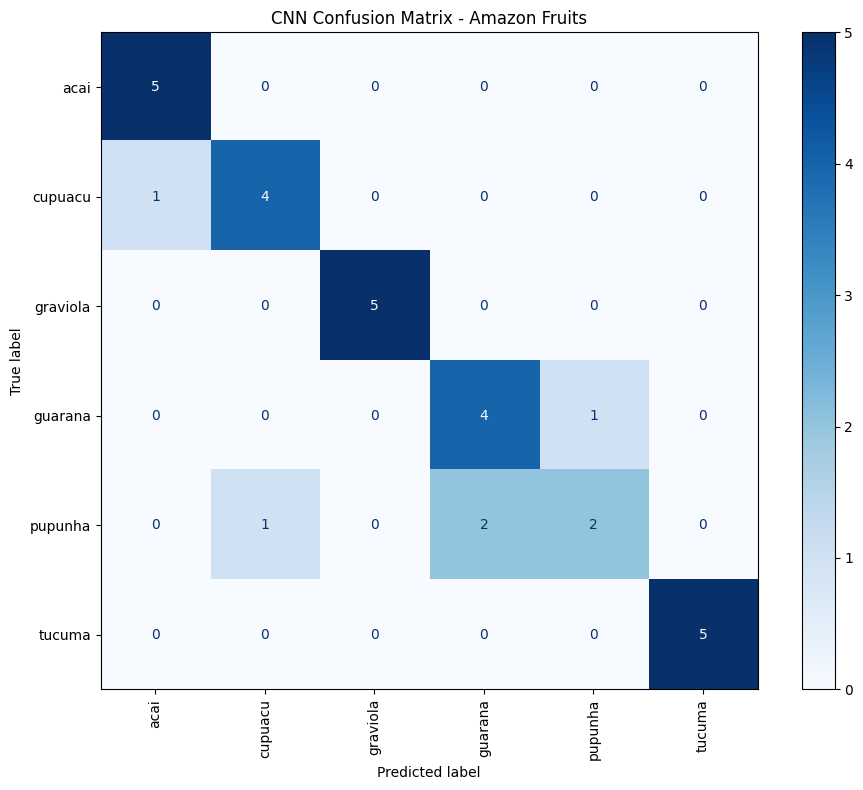

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


y_true = []
y_pred_probs = []

# Loop through the test dataset to generate predictions batch by batch
for images, labels in validation_generator:
    y_true.extend(np.argmax(labels, axis=1))
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    if len(y_true) >= validation_generator.samples:
        break # Break if we have processed all samples

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Print the Classification Report
print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Make the plot large enough to read the labels easily
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('CNN Confusion Matrix - Amazon Fruits')
plt.tight_layout()
plt.show()